In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'exp_pybamm' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NNN/../exp_pybamm.py'>

In [2]:
I = np.load('../NO/data_NO/I.npz')['arr_0']   # X
V = np.load('../NO/data_NO/V.npz')['arr_0']   # y

# Reshape from (samples, 1, 1000) to (samples, 1000)
I = I.reshape(I.shape[0], -1)
V = V.reshape(V.shape[0], -1)

test_size = 0.1
I_test = I[0:int(test_size * len(I)),:]; V_test = V[0:int(test_size * len(I)),:]
I_train = I[int(test_size * len(I)):,:]; V_train = V[int(test_size * len(I)):,:]

In [3]:
def train_mlp_multioutput(X, y, verbose=True):
    """
    Train a multi-output MLPRegressor: X -> y (vectors).
    Applies feature scaling and target scaling for stability.
    Returns:
        pipeline, (X_test, y_test, y_pred), metrics_dict
    """

    X_train, X_test = X
    y_train, y_test = y

    base_mlp = MLPRegressor(
        hidden_layer_sizes=(256, 256),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=15,
        batch_size=64,
        verbose=verbose,
    )

    pipeline = Pipeline([
        ("x_scaler", StandardScaler()),
        ("mlp", TransformedTargetRegressor(
            regressor=base_mlp,
            transformer=StandardScaler(with_mean=True, with_std=True)
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        "MSE": float(mean_squared_error(y_test, y_pred)),
        "MAE": float(mean_absolute_error(y_test, y_pred)),
        "R2": float(r2_score(y_test, y_pred)),
    }

    return pipeline, metrics

In [4]:
print("Training scikit-learn MLP (multi-output regression) ...")
model, metrics = train_mlp_multioutput(
    (I_train, I_test), (V_train, V_test), verbose=True
)
print("Test metrics:", metrics)

Training scikit-learn MLP (multi-output regression) ...
Iteration 1, loss = 0.56449432
Validation score: -0.094559
Iteration 2, loss = 0.49618893
Validation score: -0.060646
Iteration 3, loss = 0.47880619
Validation score: -0.042840
Iteration 4, loss = 0.46336182
Validation score: -0.023302
Iteration 5, loss = 0.44135395
Validation score: 0.004342
Iteration 6, loss = 0.41215140
Validation score: 0.043223
Iteration 7, loss = 0.37798138
Validation score: 0.092107
Iteration 8, loss = 0.34168810
Validation score: 0.145778
Iteration 9, loss = 0.30790455
Validation score: 0.197937
Iteration 10, loss = 0.27777151
Validation score: 0.245231
Iteration 11, loss = 0.25059797
Validation score: 0.280960
Iteration 12, loss = 0.22573336
Validation score: 0.306438
Iteration 13, loss = 0.20394456
Validation score: 0.327719
Iteration 14, loss = 0.18529429
Validation score: 0.350379
Iteration 15, loss = 0.16852539
Validation score: 0.373947
Iteration 16, loss = 0.15413829
Validation score: 0.393836
Itera

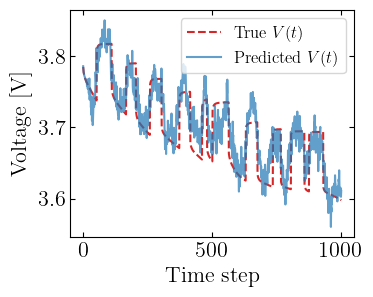

In [16]:
test = 0
i = I_test[test,:].reshape(1, -1) 
v = V_test[test,:].reshape(1, -1)

#print(i.shape, v.shape)
y_pred = model.predict(i)
# f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)
# f.subplots_adjust(hspace=0.05)

# ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
# ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
# ax[1].plot(y_pred.ravel(), label='Predicted $V(t)$', color='tab:blue')
# ax[1].legend()
# ax[0].legend()
# ax[1].set_xlabel('Time step')
# ax[0].set_ylabel('Current [A]')
# ax[1].set_ylabel('Voltage [V]')
f, ax = plt.subplots(1,1,figsize=(4,3.25))

ax.plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax.plot(y_pred.ravel(), label='Predicted $V(t)$', color='tab:blue',alpha=0.7    )
ax.legend(fontsize=12)
ax.set_xlabel('Time step')
ax.set_ylabel('Voltage [V]')
plt.tight_layout()
f.savefig('NNN_figs/NNN_pred_small.pdf')